1. Imports & Setup:

Loads standard libraries for HTTP requests, data manipulation, JSON handling, timing, and datetime parsing.
Suppresses warnings for cleaner output, then confirms successful import with a print statement.

In [49]:

import requests
import pandas as pd
import json
import time
from datetime import datetime
import warnings

warnings.filterwarnings("ignore")

print("Libraries imported successfully!")


Libraries imported successfully!


In [50]:
# Fetch installed capacity per technology per country from Eurostat (nrg_inf_epc)
# and print total + per-technology breakdown for each country.

BASE_URL = (
    "https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data/nrg_inf_epc"
)

# Leaf SIEC codes only (no aggregates, no double-counting).
# Aggregates excluded: TOTAL, RA100, RA300, RA420.
# CF is kept as a single "Combustible fuels" line (coal + gas + oil aggregated).
# Both RA420AC and RA420DC are collected here; the AC-preferred-DC-fallback
# is applied per-country in a post-processing step below.
LEAF_SIEC = {
    "CF",  # Combustible fuels (coal + gas + oil, reported as one bucket)
    "N9000",  # Nuclear fuels and other fuels n.e.c.
    "X9900",  # Other fuels n.e.c.
    "HYD",  # Hydrogen
    "RA110",  # Pure hydro power
    "RA120",  # Mixed hydro power
    "RA130",  # Pumped hydro power
    "RA200",  # Geothermal
    "RA310",  # Wind onshore
    "RA320",  # Wind offshore
    "RA410",  # Solar thermal
    "RA420AC",  # Solar PV - AC (preferred)
    "RA420DC",  # Solar PV - DC (fallback if AC not reported)
    "RA500",  # Tide, wave, ocean
}


def fetch_capacity(years=YEARS):
    rows = []
    for year in years:
        print(f"\nFetching {year}...")
        for country_name, country_code in COUNTRIES.items():
            try:
                r = requests.get(
                    BASE_URL,
                    params={"geo": country_code, "time": year, "format": "JSON"},
                    timeout=30,
                )
                if r.status_code != 200:
                    print(f"  [SKIP] {country_name}: HTTP {r.status_code}")
                    continue

                data = r.json()
                if "value" not in data or not data["value"]:
                    print(f"  [NO DATA] {country_name}")
                    continue

                # Dynamic decoder: read the actual id order and sizes from the response
                dim_ids = data["id"]
                sizes = data["size"]
                pos = {
                    d: {
                        v: k
                        for k, v in data["dimension"][d]["category"]["index"].items()
                    }
                    for d in dim_ids
                }
                siec_label = data["dimension"]["siec"]["category"]["label"]

                def decode(flat_idx):
                    coords = {}
                    for d, s in zip(reversed(dim_ids), reversed(sizes)):
                        coords[d] = pos[d][flat_idx % s]
                        flat_idx //= s
                    return coords

                kept = 0
                for key, value in data["value"].items():
                    if value is None:
                        continue
                    val = float(value)
                    if val <= 0:
                        continue

                    c = decode(int(key))
                    if c.get("operator") != "TOTAL":
                        continue
                    if c.get("plant_tec") != "CAP_NET_ELC":
                        continue
                    if c.get("siec") not in LEAF_SIEC:
                        continue

                    rows.append(
                        {
                            "country": country_name,
                            "technology": siec_label.get(c["siec"], c["siec"]),
                            "siec_code": c["siec"],
                            "capacity_mw": val,
                            "year": year,
                        }
                    )
                    kept += 1

                print(f"  [OK] {country_name}: {kept} technology records")
                time.sleep(0.5)

            except Exception as e:
                print(f"  [ERROR] {country_name}: {e}")

    df = pd.DataFrame(rows)

    # AC-preferred-DC-fallback for solar PV.
    # For each (country, year), if RA420AC is reported with a positive value, keep AC and drop DC.
    # If only RA420DC is reported, keep DC and relabel it as "Solar photovoltaic" for consistency.
    if not df.empty:
        has_ac = (
            df[df["siec_code"] == "RA420AC"]
            .groupby(["country", "year"])
            .size()
            .reset_index(name="ac_count")
        )
        # Mark rows to drop
        df = df.merge(has_ac, on=["country", "year"], how="left")
        df["ac_count"] = df["ac_count"].fillna(0)
        # Drop DC rows where AC exists for the same country/year
        drop_mask = (df["siec_code"] == "RA420DC") & (df["ac_count"] > 0)
        df = df[~drop_mask].drop(columns=["ac_count"]).copy()
        # Relabel surviving PV rows so AC and DC fallback share a single label
        pv_mask = df["siec_code"].isin(["RA420AC", "RA420DC"])
        df.loc[pv_mask, "technology"] = "Solar photovoltaic"

    return df


df = fetch_capacity(YEARS)

# Print total + breakdown per country
for country in df["country"].unique():
    sub = df[df["country"] == country]
    total = sub["capacity_mw"].sum()
    print("\n" + "=" * 60)
    print(country)
    print("=" * 60)
    print(f"TOTAL: {total:,.0f} MW\n")
    print("BREAKDOWN:")
    breakdown = (
        sub.groupby("technology")["capacity_mw"].sum().sort_values(ascending=False)
    )
    for tech, mw in breakdown.items():
        share = mw / total * 100
        print(f"  {tech:<45} {mw:>10,.0f} MW  ({share:>5.1f}%)")



Fetching 2024...
  [OK] France: 11 technology records
  [OK] Spain: 11 technology records
  [OK] Austria: 7 technology records
  [OK] Bulgaria: 8 technology records
  [OK] Belgium: 9 technology records
  [OK] Greece: 6 technology records
  [OK] Czechia: 8 technology records
  [OK] Hungary: 8 technology records

France
TOTAL: 158,458 MW

BREAKDOWN:
  Nuclear fuels and other fuels n.e.c.              61,400 MW  ( 38.7%)
  Solar photovoltaic                                25,083 MW  ( 15.8%)
  Wind on shore                                     22,747 MW  ( 14.4%)
  Combustible fuels                                 20,411 MW  ( 12.9%)
  Pure hydro power                                  18,922 MW  ( 11.9%)
  Mixed hydro power                                  5,375 MW  (  3.4%)
  Pumped hydro power                                 1,728 MW  (  1.1%)
  Wind off shore                                     1,494 MW  (  0.9%)
  Other fuels n.e.c.                                 1,089 MW  (  0.7%)
 

2. Configuration – Countries, Technologies & Eurostat Datasets

Defines eight countries (FR, ES, AT, BG, BE, EL, CZ, HU) and eleven energy technology types
(from Solar and Wind to Coal, Gas, and Nuclear) used throughout the analysis.
Scopes the analysis to **2024** and maps three Eurostat price datasets covering
household, industry, and all-consumer electricity prices.

In [51]:
COUNTRIES = {
    "France": "FR",
    "Spain": "ES",
    "Austria": "AT",
    "Bulgaria": "BG",
    "Belgium": "BE",
    "Greece": "EL",
    "Czechia": "CZ",
    "Hungary": "HU",
}

YEARS = [2024]

print("Configuration set successfully!")
print(f"Countries: {len(COUNTRIES)}")
print(f"Years: {YEARS}")


Configuration set successfully!
Countries: 8
Years: [2024]


3. Fetch Installed Capacity per Technology per Country from Eurostat

Queries the `nrg_inf_epc` endpoint per country and year, decoding the JSON-stat response
dynamically. Filters to `operator=TOTAL`, `plant_tec=CAP_NET_ELC`, and leaf SIEC codes only
(aggregates `TOTAL`, `RA100`, `RA300`, `RA420` are excluded to prevent double-counting;
`CF` is kept as a single "Combustible fuels" line). For solar PV, prefers `RA420AC` and
falls back to `RA420DC` when AC is not reported. Rate-limited with a 0.5s delay between
calls. Returns a long-format DataFrame and prints total + per-technology breakdown per country.

In [52]:
# Fetch installed capacity per technology per country from Eurostat (nrg_inf_epc)
# and print total + per-technology breakdown for each country.

BASE_URL = (
    "https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data/nrg_inf_epc"
)

# Leaf SIEC codes only (no aggregates, no double-counting).
# Aggregates excluded: TOTAL, RA100, RA300, RA420.
# CF is kept as a single "Combustible fuels" line (coal + gas + oil aggregated).
# Both RA420AC and RA420DC are collected here; the AC-preferred-DC-fallback
# is applied per-country in a post-processing step below.
LEAF_SIEC = {
    "CF",  # Combustible fuels (coal + gas + oil, reported as one bucket)
    "N9000",  # Nuclear fuels and other fuels n.e.c.
    "X9900",  # Other fuels n.e.c.
    "HYD",  # Hydrogen
    "RA110",  # Pure hydro power
    "RA120",  # Mixed hydro power
    "RA130",  # Pumped hydro power
    "RA200",  # Geothermal
    "RA310",  # Wind onshore
    "RA320",  # Wind offshore
    "RA410",  # Solar thermal
    "RA420AC",  # Solar PV - AC (preferred)
    "RA420DC",  # Solar PV - DC (fallback if AC not reported)
    "RA500",  # Tide, wave, ocean
}


def fetch_capacity(years=YEARS):
    rows = []
    for year in years:
        print(f"\nFetching {year}...")
        for country_name, country_code in COUNTRIES.items():
            try:
                r = requests.get(
                    BASE_URL,
                    params={"geo": country_code, "time": year, "format": "JSON"},
                    timeout=30,
                )
                if r.status_code != 200:
                    print(f"  [SKIP] {country_name}: HTTP {r.status_code}")
                    continue

                data = r.json()
                if "value" not in data or not data["value"]:
                    print(f"  [NO DATA] {country_name}")
                    continue

                # Dynamic decoder: read the actual id order and sizes from the response
                dim_ids = data["id"]
                sizes = data["size"]
                pos = {
                    d: {
                        v: k
                        for k, v in data["dimension"][d]["category"]["index"].items()
                    }
                    for d in dim_ids
                }
                siec_label = data["dimension"]["siec"]["category"]["label"]

                def decode(flat_idx):
                    coords = {}
                    for d, s in zip(reversed(dim_ids), reversed(sizes)):
                        coords[d] = pos[d][flat_idx % s]
                        flat_idx //= s
                    return coords

                kept = 0
                for key, value in data["value"].items():
                    if value is None:
                        continue
                    val = float(value)
                    if val <= 0:
                        continue

                    c = decode(int(key))
                    if c.get("operator") != "TOTAL":
                        continue
                    if c.get("plant_tec") != "CAP_NET_ELC":
                        continue
                    if c.get("siec") not in LEAF_SIEC:
                        continue

                    rows.append(
                        {
                            "country": country_name,
                            "technology": siec_label.get(c["siec"], c["siec"]),
                            "siec_code": c["siec"],
                            "capacity_mw": val,
                            "year": year,
                        }
                    )
                    kept += 1

                print(f"  [OK] {country_name}: {kept} technology records")
                time.sleep(0.5)

            except Exception as e:
                print(f"  [ERROR] {country_name}: {e}")

    df = pd.DataFrame(rows)

    # AC-preferred-DC-fallback for solar PV.
    # For each (country, year), if RA420AC is reported with a positive value, keep AC and drop DC.
    # If only RA420DC is reported, keep DC and relabel it as "Solar photovoltaic" for consistency.
    if not df.empty:
        has_ac = (
            df[df["siec_code"] == "RA420AC"]
            .groupby(["country", "year"])
            .size()
            .reset_index(name="ac_count")
        )
        # Mark rows to drop
        df = df.merge(has_ac, on=["country", "year"], how="left")
        df["ac_count"] = df["ac_count"].fillna(0)
        # Drop DC rows where AC exists for the same country/year
        drop_mask = (df["siec_code"] == "RA420DC") & (df["ac_count"] > 0)
        df = df[~drop_mask].drop(columns=["ac_count"]).copy()
        # Relabel surviving PV rows so AC and DC fallback share a single label
        pv_mask = df["siec_code"].isin(["RA420AC", "RA420DC"])
        df.loc[pv_mask, "technology"] = "Solar photovoltaic"

    return df


df = fetch_capacity(YEARS)

# Print total + breakdown per country
for country in df["country"].unique():
    sub = df[df["country"] == country]
    total = sub["capacity_mw"].sum()
    print("\n" + "=" * 60)
    print(country)
    print("=" * 60)
    print(f"TOTAL: {total:,.0f} MW\n")
    print("BREAKDOWN:")
    breakdown = (
        sub.groupby("technology")["capacity_mw"].sum().sort_values(ascending=False)
    )
    for tech, mw in breakdown.items():
        share = mw / total * 100
        print(f"  {tech:<45} {mw:>10,.0f} MW  ({share:>5.1f}%)")



Fetching 2024...
  [OK] France: 11 technology records
  [OK] Spain: 11 technology records
  [OK] Austria: 7 technology records
  [OK] Bulgaria: 8 technology records
  [OK] Belgium: 9 technology records
  [OK] Greece: 6 technology records
  [OK] Czechia: 8 technology records
  [OK] Hungary: 8 technology records

France
TOTAL: 158,458 MW

BREAKDOWN:
  Nuclear fuels and other fuels n.e.c.              61,400 MW  ( 38.7%)
  Solar photovoltaic                                25,083 MW  ( 15.8%)
  Wind on shore                                     22,747 MW  ( 14.4%)
  Combustible fuels                                 20,411 MW  ( 12.9%)
  Pure hydro power                                  18,922 MW  ( 11.9%)
  Mixed hydro power                                  5,375 MW  (  3.4%)
  Pumped hydro power                                 1,728 MW  (  1.1%)
  Wind off shore                                     1,494 MW  (  0.9%)
  Other fuels n.e.c.                                 1,089 MW  (  0.7%)
 

4. Visualize Installed Capacity per Technology per Country

Renders a stacked horizontal bar chart with one bar per country, segments colored by
technology group. Countries are sorted by total capacity (largest at top), and each
bar is annotated with its total in GW. Fine-grained SIEC categories are grouped into
seven buckets (Hydro, Wind, Solar PV, Solar thermal, Nuclear, Combustible fuels,
Geothermal, Other) for readability, using intuitive colors per technology.

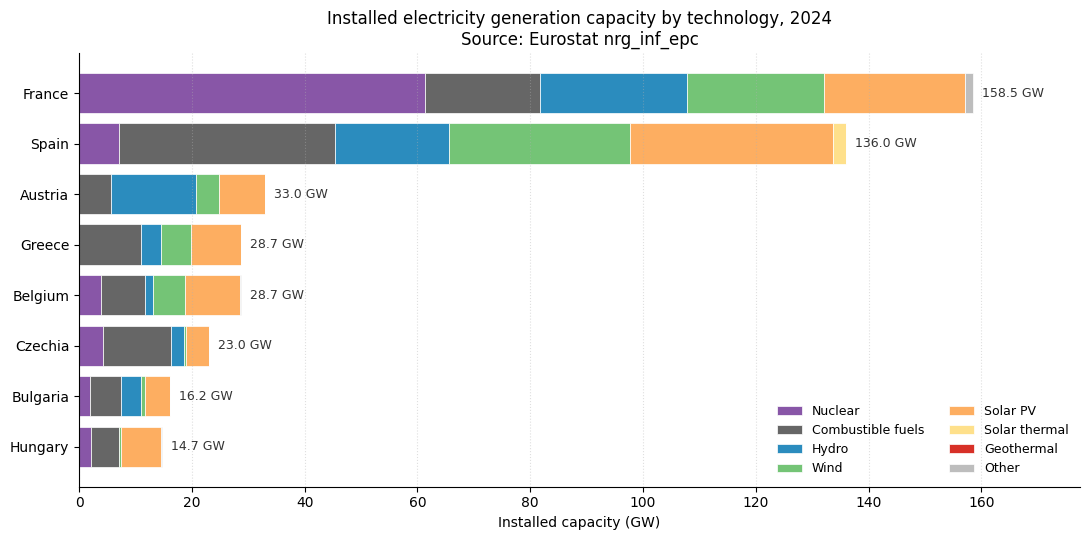

In [53]:
# Stacked horizontal bar chart: installed capacity per technology per country.
# Countries sorted by total capacity (largest at top). Capacity shown in GW.

import matplotlib.pyplot as plt
import numpy as np

# Group fine-grained technologies into ~7 readable categories
TECH_GROUPS = {
    "Pure hydro power": "Hydro",
    "Mixed hydro power": "Hydro",
    "Pumped hydro power": "Hydro",
    "Wind on shore": "Wind",
    "Wind off shore": "Wind",
    "Solar photovoltaic": "Solar PV",
    "Solar thermal": "Solar thermal",
    "Nuclear fuels and other fuels n.e.c.": "Nuclear",
    "Combustible fuels": "Combustible fuels",
    "Geothermal": "Geothermal",
    "Tide, wave, ocean": "Other",
    "Other fuels n.e.c.": "Other",
    "Hydrogen (H2)": "Other",
}

# Display order (top to bottom in legend, left to right in each bar)
TECH_ORDER = [
    "Nuclear",
    "Combustible fuels",
    "Hydro",
    "Wind",
    "Solar PV",
    "Solar thermal",
    "Geothermal",
    "Other",
]

# Intuitive colors
TECH_COLORS = {
    "Nuclear": "#8856a7",  # purple
    "Combustible fuels": "#666666",  # dark grey
    "Hydro": "#2b8cbe",  # blue
    "Wind": "#74c476",  # green
    "Solar PV": "#fdae61",  # orange
    "Solar thermal": "#fee08b",  # light yellow
    "Geothermal": "#d73027",  # red
    "Other": "#bdbdbd",  # light grey
}

# Aggregate to country × tech_group, in GW
plot_df = df.copy()
plot_df["tech_group"] = plot_df["technology"].map(TECH_GROUPS).fillna("Other")
plot_df["capacity_gw"] = plot_df["capacity_mw"] / 1000.0

pivot = (
    plot_df.groupby(["country", "tech_group"])["capacity_gw"]
    .sum()
    .unstack(fill_value=0)
    .reindex(columns=TECH_ORDER, fill_value=0)
)

# Sort countries by total capacity, largest at top
pivot = pivot.loc[pivot.sum(axis=1).sort_values().index]
totals = pivot.sum(axis=1)

# Plot
fig, ax = plt.subplots(figsize=(11, 5.5))
left = np.zeros(len(pivot))
y = np.arange(len(pivot))

for tech in TECH_ORDER:
    values = pivot[tech].values
    ax.barh(
        y,
        values,
        left=left,
        color=TECH_COLORS[tech],
        label=tech,
        edgecolor="white",
        linewidth=0.5,
    )
    left += values

# Total annotations at the end of each bar
for i, total in enumerate(totals):
    ax.text(
        total + max(totals) * 0.01,
        i,
        f"{total:,.1f} GW",
        va="center",
        ha="left",
        fontsize=9,
        color="#333333",
    )

ax.set_yticks(y)
ax.set_yticklabels(pivot.index)
ax.set_xlabel("Installed capacity (GW)")
year_str = ", ".join(str(y) for y in YEARS)
ax.set_title(
    f"Installed electricity generation capacity by technology, {year_str}\nSource: Eurostat nrg_inf_epc"
)
ax.set_xlim(0, max(totals) * 1.12)  # headroom for labels
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(loc="lower right", frameon=False, ncol=2, fontsize=9)
ax.grid(axis="x", linestyle=":", alpha=0.4)

plt.tight_layout()
plt.show()
